In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Load dataset
df = pd.read_csv("Demotivational.csv")

# Preview
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.353130e+09,2891,i.imgur.com,13c9i5,"""Distinction""",fudgemunk,4711,1820,59,http://www.reddit.com/r/Demotivational/comment...,NaN,NaN,False,http://e.thumbs.redditmedia.com/9qXi1nh4HzavyV...,t5_2qm1v,False,NaN,NaN,False,t3_13c9i5,http://i.imgur.com/M3b2i.png,NaN
1,1.357066e+09,2553,imgur.com,15s3nr,This demotivational is the reason why I first ...,RafTheKillJoy,5925,3372,42,http://www.reddit.com/r/Demotivational/comment...,NaN,NaN,False,http://b.thumbs.redditmedia.com/8jvXDhtQjF58U-...,t5_2qm1v,False,NaN,NaN,False,t3_15s3nr,http://imgur.com/tLY4z,NaN
2,1.353607e+09,2392,imgur.com,13mnds,The Truth,sheepsdontcry,4288,1896,73,http://www.reddit.com/r/Demotivational/comment...,NaN,NaN,False,http://c.thumbs.redditmedia.com/FbGSpS9tlH_sSq...,t5_2qm1v,False,NaN,NaN,False,t3_13mnds,http://imgur.com/CaCZc,NaN
3,1.359563e+09,2275,i.imgur.com,17kf72,Sex and Death,peteypump,4394,2119,67,http://www.reddit.com/r/Demotivational/comment...,NaN,NaN,False,http://a.thumbs.redditmedia.com/1Dr4c-1jCV4lQ1...,t5_2qm1v,False,NaN,NaN,False,t3_17kf72,http://i.imgur.com/Icsw9hN.jpg,NaN
4,1.365104e+09,2201,img.izismile.com,1bojm3,I wish this weren't so true,nthensome,3535,1334,30,http://www.reddit.com/r/Demotivational/comment...,NaN,NaN,False,http://c.thumbs.redditmedia.com/PPtKWu0sn4uAXm...,t5_2qm1v,False,NaN,NaN,False,t3_1bojm3,http://img.izismile.com/img/img6/20130326/640/...,NaN


In [3]:
print(df.shape)
print(df.info())
print(df.describe())

# Check missing values
print(df.isnull().sum())

(1000, 22)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             1000 non-null   float64
 1   score                   1000 non-null   int64  
 2   domain                  1000 non-null   str    
 3   id                      1000 non-null   str    
 4   title                   1000 non-null   str    
 5   author                  947 non-null    str    
 6   ups                     1000 non-null   int64  
 7   downs                   1000 non-null   int64  
 8   num_comments            1000 non-null   int64  
 9   permalink               1000 non-null   str    
 10  selftext                0 non-null      float64
 11  link_flair_text         3 non-null      str    
 12  over_18                 1000 non-null   bool   
 13  thumbnail               1000 non-null   str    
 14  subreddit_id            1000 non-null   s

In [5]:
# Fill numeric columns
for col in df.select_dtypes(include=np.number):
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns
for col in df.select_dtypes(include=['object', 'string']):
    df[col] = df[col].fillna(df[col].mode()[0])

In [7]:
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.353130e+09,2891,i.imgur.com,13c9i5,"""Distinction""",fudgemunk,4711,1820,59,http://www.reddit.com/r/Demotivational/comment...,NaN,Sad Seal of Approval,False,http://e.thumbs.redditmedia.com/9qXi1nh4HzavyV...,t5_2qm1v,False,original-content,OC,False,t3_13c9i5,http://i.imgur.com/M3b2i.png,NaN
1,1.357066e+09,2553,imgur.com,15s3nr,This demotivational is the reason why I first ...,RafTheKillJoy,5925,3372,42,http://www.reddit.com/r/Demotivational/comment...,NaN,Sad Seal of Approval,False,http://b.thumbs.redditmedia.com/8jvXDhtQjF58U-...,t5_2qm1v,False,original-content,OC,False,t3_15s3nr,http://imgur.com/tLY4z,NaN
2,1.353607e+09,2392,imgur.com,13mnds,The Truth,sheepsdontcry,4288,1896,73,http://www.reddit.com/r/Demotivational/comment...,NaN,Sad Seal of Approval,False,http://c.thumbs.redditmedia.com/FbGSpS9tlH_sSq...,t5_2qm1v,False,original-content,OC,False,t3_13mnds,http://imgur.com/CaCZc,NaN
3,1.359563e+09,2275,i.imgur.com,17kf72,Sex and Death,peteypump,4394,2119,67,http://www.reddit.com/r/Demotivational/comment...,NaN,Sad Seal of Approval,False,http://a.thumbs.redditmedia.com/1Dr4c-1jCV4lQ1...,t5_2qm1v,False,original-content,OC,False,t3_17kf72,http://i.imgur.com/Icsw9hN.jpg,NaN
4,1.365104e+09,2201,img.izismile.com,1bojm3,I wish this weren't so true,nthensome,3535,1334,30,http://www.reddit.com/r/Demotivational/comment...,NaN,Sad Seal of Approval,False,http://c.thumbs.redditmedia.com/PPtKWu0sn4uAXm...,t5_2qm1v,False,original-content,OC,False,t3_1bojm3,http://img.izismile.com/img/img6/20130326/640/...,NaN


In [8]:
print(df.columns)
df.head()

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')


,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.353130e+09,2891,i.imgur.com,13c9i5,"""Distinction""",fudgemunk,4711,1820,59,http://www.reddit.com/r/Demotivational/comment...,NaN,Sad Seal of Approval,False,http://e.thumbs.redditmedia.com/9qXi1nh4HzavyV...,t5_2qm1v,False,original-content,OC,False,t3_13c9i5,http://i.imgur.com/M3b2i.png,NaN
1,1.357066e+09,2553,imgur.com,15s3nr,This demotivational is the reason why I first ...,RafTheKillJoy,5925,3372,42,http://www.reddit.com/r/Demotivational/comment...,NaN,Sad Seal of Approval,False,http://b.thumbs.redditmedia.com/8jvXDhtQjF58U-...,t5_2qm1v,False,original-content,OC,False,t3_15s3nr,http://imgur.com/tLY4z,NaN
2,1.353607e+09,2392,imgur.com,13mnds,The Truth,sheepsdontcry,4288,1896,73,http://www.reddit.com/r/Demotivational/comment...,NaN,Sad Seal of Approval,False,http://c.thumbs.redditmedia.com/FbGSpS9tlH_sSq...,t5_2qm1v,False,original-content,OC,False,t3_13mnds,http://imgur.com/CaCZc,NaN
3,1.359563e+09,2275,i.imgur.com,17kf72,Sex and Death,peteypump,4394,2119,67,http://www.reddit.com/r/Demotivational/comment...,NaN,Sad Seal of Approval,False,http://a.thumbs.redditmedia.com/1Dr4c-1jCV4lQ1...,t5_2qm1v,False,original-content,OC,False,t3_17kf72,http://i.imgur.com/Icsw9hN.jpg,NaN
4,1.365104e+09,2201,img.izismile.com,1bojm3,I wish this weren't so true,nthensome,3535,1334,30,http://www.reddit.com/r/Demotivational/comment...,NaN,Sad Seal of Approval,False,http://c.thumbs.redditmedia.com/PPtKWu0sn4uAXm...,t5_2qm1v,False,original-content,OC,False,t3_1bojm3,http://img.izismile.com/img/img6/20130326/640/...,NaN


In [11]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

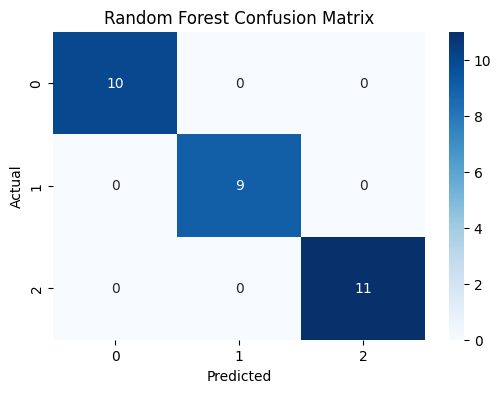

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()